In [3]:
uv sync --manifest-path pyproject.sam3.toml

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import sys
import numpy as np
from PIL import Image
from IPython.display import HTML

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.sam import SamDetector
from fashion_detector.models.vision_llm import VisionLlmDetector
from fashion_detector.utils import (
    load_image,
    generate_interactive_html,
    visualize_detections,
    display_img,
    user_categories,
    execute_detection,
    clean_categories
)

# Load configuration
config = Config("config/config.yaml")
llm_detector = VisionLlmDetector(config)


# Initialize SAM Detector
# detector = SamDetector(config)
# detector.load_model()
from fashion_detector.models.sam3_segmenter import SamSegmenter
config.models['sam']['name'] = "facebook/sam2.1-hiera-small"
# config.models['sam']['name'] = "facebook/sam3"
sam_segmenter = SamSegmenter(config)

[2026-07-23 09:16:36] [INFO] [fashion_detector:config.py:166] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-23 09:16:36] [INFO] [fashion_detector:sam3_segmenter.py:247] - Factory routing execution architecture -> Sam2Detector Subclass


In [2]:
import json
with open("detections.json", "r") as f:
    detections = json.load(f)

[2026-07-23 09:16:53] [INFO] [fashion_detector:utils.py:118] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 09:16:54] [INFO] [fashion_detector:utils.py:118] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 09:16:54] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-23 09:16:54] [INFO] [fashion_detector:vision_llm.py:160] - Querying Vision LLM openai/google/gemma-4-e2b via LiteLLM...

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

[2026-07-23 09:16:55] [ERROR] [fashion_detector:vision_llm.py:185] - Error calling or parsing Vision LLM response: litellm.InternalServerError: InternalServerError: OpenAIException - Connection error.
[2026-07-23 09:16:55] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 1.5221 seconds
[2026-07-23 09:16:55] [INFO] [fashion_d


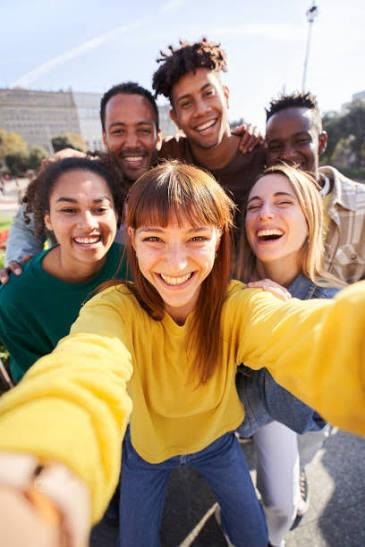

[]

In [3]:
image_path = detections[0]['image_path']
image = load_image(image_path)
w, h = image.size
execute_detection(image_path, detector=llm_detector, visualize=True)

In [4]:
image = load_image(detections[0]['image_path'])
# boxes = [det['box'] for det in detections[0]['detections']]
box_inputs = detections[0]['detections']
# config.models['sam']['name'] = "facebook/sam2.1-hiera-small"  # Ensure the correct model name is set in the config
config.models['sam']['name'] = "facebook/sam3"  # Ensure the correct model name is set in the config

segmented_image = sam_segmenter.segment_with_boxes(image, box_inputs)
# Pass your image and target coordinates to get list of separate images
cutout_images = sam_segmenter.extract_segmented_parts(image, box_inputs)

[2026-07-23 09:18:03] [INFO] [fashion_detector:utils.py:118] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 09:18:03] [INFO] [fashion_detector:logging.py:98] - Starting: sam2_box_segmentation
[2026-07-23 09:18:03] [INFO] [fashion_detector:sam3_segmenter.py:29] - Loading SAM 2 model: facebook/sam2.1-hiera-small on device: mps
[2026-07-23 09:18:08] [INFO] [fashion_detector:sam3_segmenter.py:40] - SAM 2 model loaded successfully.
[2026-07-23 09:18:10] [INFO] [fashion_detector:logging.py:103] - Completed: sam2_box_segmentation in 6.3649 seconds
[2026-07-23 09:18:10] [INFO] [fashion_detector:logging.py:98] - Starting: sam2_box_extraction
[2026-07-23 09:18:10] [INFO] [fashion_detector:logging.py:103] - Completed: sam2_box_extraction in 0.3908 seconds


In [7]:
from typing import List
import math
import matplotlib.pyplot as plt
from PIL import Image

def display_imageGrid(images: List[Image.Image], imgs_per_row: int = 3, max_width: int = 15) -> None:
    """
    Displays a list of PIL Images in a grid layout inside a Jupyter Notebook cell.
    
    Args:
        images: List of PIL.Image.Image instances to display.
        imgs_per_row: Number of images per row (e.g., 2 or 3).
        max_width: Maximum width of the entire figure layout in inches.
        
    Raises:
        TypeError: If input validation fails for types or structures.
        ValueError: If imgs_per_row is less than 1 or images list is empty.
    """
    # 1. Input Type and Value Validations
    if not isinstance(images, list):
        raise TypeError(f"Expected a list for 'images', but got {type(images).__name__}.")
    
    if not images:
        raise ValueError("The 'images' list cannot be empty.")
        
    for idx, img in enumerate(images):
        if not isinstance(img, Image.Image):
            raise TypeError(
                f"Element at index {idx} is not a valid PIL Image. Got {type(img).__name__}."
            )
            
    if not isinstance(imgs_per_row, int) or isinstance(imgs_per_row, bool):
        raise TypeError(f"Expected an integer for 'imgs_per_row', but got {type(imgs_per_row).__name__}.")
        
    if imgs_per_row < 1:
        raise ValueError(f"Value of 'imgs_per_row' must be 1 or greater. Got {imgs_per_row}.")

    # 2. Grid Dimensions Calculations
    num_images = len(images)
    num_rows = math.ceil(num_images / imgs_per_row)
    
    # Dynamically scale height proportionally to maintain reasonable image aspect ratios
    fig_width = max_width
    fig_height = (fig_width / imgs_per_row) * num_rows

    # 3. Render Canvas
    fig, axes = plt.subplots(num_rows, imgs_per_row, figsize=(fig_width, fig_height))
    
    # Flatten axes matrix to a simple 1D array for easier iteration
    # Handle edge case where a 1x1 subplots call returns a single axis object rather than an array
    if num_images == 1 and imgs_per_row == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    # 4. Populate Grid Subplots
    for i in range(len(axes)):
        if i < num_images:
            # Display image data arrays safely
            axes[i].imshow(images[i])
            axes[i].axis("off")  # Suppress pixel position coordinate ticks
        else:
            # Hide leftover empty subplot containers in the final grid row
            axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


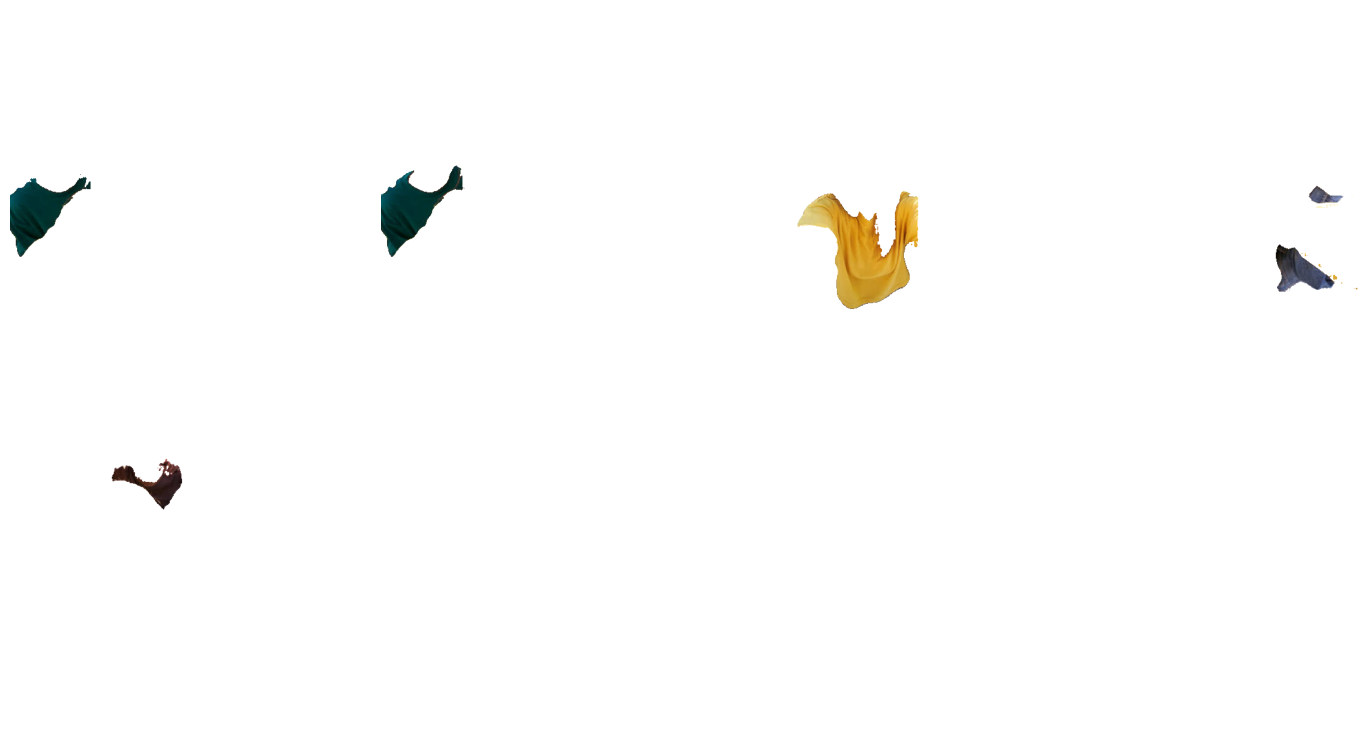

In [9]:
display_imageGrid(cutout_images, imgs_per_row=4)